기상 데이터를 이용한 119신고 접수건수 예측

In [ ]:
!pip install holidayskr flaml pycaret catboost category_encoders -q
!pip install "numpy<2.0" --force-reinstall

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import json

from holidayskr import is_holiday # add_date_features
from datetime import timedelta # create_prev_year_lookup

from catboost import CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit
from flaml import AutoML
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', None)

In [ ]:
base_url = 'https://raw.githubusercontent.com/s0nghyunje0ng/2025-weather-bigdata-contest/safety/topic2_safety/data/'

call119_train = pd.read_csv(base_url + 'raw/call119_train.csv')
cat119_train = pd.read_csv(base_url + 'raw/cat119_train.csv')
call119_test = pd.read_csv(base_url + 'raw/test_call119.csv', encoding='euc-kr')
cat119_test = pd.read_csv(base_url + 'raw/test_cat119.csv', encoding='euc-kr')

# 전처리

In [ ]:
def preprocess_data(df: pd.DataFrame, df_type: str) -> pd.DataFrame:
    df_processed = df.copy() # 원본 데이터프레임 복사

    # 컬럼명을 소문자로 변경하고 불필요한 접두사 제거
    df_processed.columns = df_processed.columns.str.lower().str.replace(r'^[a-z0-9_]+\.', '', regex=True)

    # 'address_city' 컬럼 제거
    df_processed = df_processed.drop(columns=['address_city'])
    # 'address_gu'와 'sub_address'를 결합하여 'full_address' 컬럼 생성
    df_processed['full_address'] = df_processed['address_gu'].astype(str) + '_' + df_processed['sub_address'].astype(str)
    df_processed = df_processed.drop(columns=['sub_address'])

    if df_type == 'cat':
        # 'cat' 유형일 경우 'cat'과 'sub_cat'을 결합하여 'full_cat' 컬럼 생성
        df_processed['full_cat'] = df_processed['cat'].astype(str) + '_' + df_processed['sub_cat'].astype(str)
        df_processed = df_processed.drop(columns=['sub_cat'])
        # 범주형(category) 컬럼 타입 지정
        for col in ['address_gu', 'full_address', 'stn', 'cat', 'full_cat']:
            df_processed[col] = df_processed[col].astype('category')

    elif df_type == 'call':
        # 'call' 유형일 경우 -99.0 값을 NaN으로 대체
        df_processed = df_processed.replace(-99.0, np.nan)
        # 범주형(category) 컬럼 타입 지정
        for col in ['address_gu', 'full_address', 'stn']:
            df_processed[col] = df_processed[col].astype('category')

    return df_processed

In [ ]:
call119_train_processed = preprocess_data(call119_train, 'call')
cat119_train_processed = preprocess_data(cat119_train, 'cat')

call119_test_processed = preprocess_data(call119_test, 'call')
cat119_test_processed = preprocess_data(cat119_test, 'cat')

category_dtypes = {
    'call': {col: call119_train_processed[col].dtype for col in ['address_gu', 'full_address', 'stn']},
    'cat': {col: cat119_train_processed[col].dtype for col in ['address_gu', 'full_address', 'stn', 'cat', 'full_cat']}
}

call119_test_processed = call119_test_processed.astype(category_dtypes['call'])
cat119_test_processed = cat119_test_processed.astype(category_dtypes['cat'])

In [ ]:
from typing_extensions import final

def merge_data(df_call: pd.DataFrame, df_cat: pd.DataFrame) -> pd.DataFrame:
    df_call = df_call.copy()
    df_cat = df_cat.copy()

    df_cat['cat'] = df_cat['cat'].astype(str).replace({'화재': '기타화재', '기타': '기타화재'})
    df_cat['cat'] = df_cat['cat'].astype('category')

    unique_keys = df_call[['tm', 'full_address']].drop_duplicates()
    all_categories = ['구급', '구조', '기타화재']
    scaffold_df = unique_keys.merge(pd.DataFrame({'cat': all_categories}), how='cross')

    cat_agg = df_cat.groupby(
        ['tm', 'full_address', 'cat'],
        as_index=False,
        observed=True
    )['call_count'].sum()

    long_format_calls = pd.merge(
        scaffold_df,
        cat_agg,
        on=['tm', 'full_address', 'cat'],
        how='left'
    )
    long_format_calls['call_count'] = long_format_calls['call_count'].fillna(0).astype(int)

    final_df = pd.merge(
        long_format_calls,
        df_call.drop(columns=['call_count']),
        on=['tm', 'full_address'],
        how='left'
    )
    final_df['cat'] = final_df['cat'].astype('category')

    return final_df

In [ ]:
train_merged = merge_data(call119_train_processed, cat119_train_processed)
display(train_merged.head(9))

cat119_test_processed['call_count'] = np.nan
test_merged = merge_data(call119_test_processed, cat119_test_processed)
display(test_merged.head(9))

,tm,full_address,cat,call_count,address_gu,stn,ta_max,ta_min,ta_max_min,hm_min,hm_max,ws_max,ws_ins_max,rn_day
0,20200501,강서구_대저2동,구급,1,강서구,904,23.7,16.6,7.1,63.2,90.3,5.8,10.6,0.0
1,20200501,강서구_대저2동,구조,0,강서구,904,23.7,16.6,7.1,63.2,90.3,5.8,10.6,0.0
2,20200501,강서구_대저2동,기타화재,0,강서구,904,23.7,16.6,7.1,63.2,90.3,5.8,10.6,0.0
3,20200501,강서구_천성동,구급,0,강서구,921,24.3,15.4,8.9,64.2,96.4,4.8,8.6,0.0
4,20200501,강서구_천성동,구조,1,강서구,921,24.3,15.4,8.9,64.2,96.4,4.8,8.6,0.0
5,20200501,강서구_천성동,기타화재,0,강서구,921,24.3,15.4,8.9,64.2,96.4,4.8,8.6,0.0
6,20200501,금정구_금사동,구급,1,금정구,940,25.6,17.2,8.4,46.6,76.4,4.8,8.3,0.0
7,20200501,금정구_금사동,구조,0,금정구,940,25.6,17.2,8.4,46.6,76.4,4.8,8.3,0.0
8,20200501,금정구_금사동,기타화재,0,금정구,940,25.6,17.2,8.4,46.6,76.4,4.8,8.3,0.0


,tm,full_address,cat,call_count,address_gu,stn,ta_max,ta_min,ta_max_min,hm_min,hm_max,ws_max,ws_ins_max,rn_day
0,20240501,강서구_대저2동,구급,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
1,20240501,강서구_대저2동,구조,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
2,20240501,강서구_대저2동,기타화재,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
3,20240501,강서구_생곡동,구급,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
4,20240501,강서구_생곡동,구조,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
5,20240501,강서구_생곡동,기타화재,0,강서구,904,18.5,11.1,7.4,42.5,82.5,6.5,11.6,0.0
6,20240501,강서구_송정동,구급,0,강서구,937,16.9,9.9,7.0,55.3,93.9,4.5,9.7,0.0
7,20240501,강서구_송정동,구조,0,강서구,937,16.9,9.9,7.0,55.3,93.9,4.5,9.7,0.0
8,20240501,강서구_송정동,기타화재,0,강서구,937,16.9,9.9,7.0,55.3,93.9,4.5,9.7,0.0


# 결측치 보간

In [ ]:
# 인접 관측소 딕셔너리 로드
response = requests.get(base_url + 'processed/busan_stn_neighbors_with_distance.json')
stn_neighbors_dict = json.loads(response.text)
# 딕셔너리 키(관측소 ID)를 정수형으로 변환
stn_neighbors_dict = {int(k): v for k, v in stn_neighbors_dict.items()}

def impute_weather_data_IDW(df: pd.DataFrame, stn_neighbors_dict: dict) -> pd.DataFrame:
    """거리 역가중 평균(IDW)을 사용해 날씨 데이터 결측치를 보간합니다."""
    df_processed = df.drop(columns=['ta_max_min']).copy() # 원본 데이터프레 복사 및 불필요 컬럼 제거
    df_processed['tm'] = pd.to_datetime(df_processed['tm'], format='%Y%m%d') # 'tm' 컬럼을 datetime 형식으로 변환

    # 보간할 날씨 관련 컬럼 목록
    cols_to_impute = ['ta_max', 'ta_min', 'hm_max', 'hm_min', 'ws_max', 'ws_ins_max', 'rn_day']
    print(f"🔴 IDW 보간 전 결측 현황\n{df_processed[cols_to_impute].isna().sum()}")

    # 보간을 위한 핵심 컬럼과 날씨 컬럼만 추출
    keys = ['tm', 'stn'] # 기준이 되는 시간과 관측소 컬럼
    df_imputation = df_processed[keys + cols_to_impute].copy()

    # 동일한 'tm', 'stn' 조합에 여러 값이 있을 경우 평균으로 집계 (중복 데이터 처리)
    df_imputation = df_imputation.groupby(keys, as_index=False, observed=True).mean()

    # 인덱스 설정 및 정렬하여 데이터 접근 효율화
    df_imputation.set_index(keys, inplace=True)
    df_imputation.sort_index(inplace=True)

    # 결측치가 있는 행의 인덱스 추출
    missing_indices = df_imputation[df_imputation.isnull().any(axis=1)].index

    # 추출된 결측치 인덱스를 반복하며 보간 수행
    for idx in missing_indices:
        current_tm, current_stn = idx # 현재 행의 시간과 관측소 ID
        neighbors = stn_neighbors_dict.get(current_stn, []) # 현재 관측소의 인접 관측소 정보 가져오기

        # 보간할 각 컬럼에 대해 반복
        for col in cols_to_impute:
            if pd.isnull(df_imputation.loc[idx, col]): # 현재 컬럼에 결측치가 있다면
                weighted_sum, weight_sum = 0, 0 # 가중 합계와 가중치 합계 초기화

                # 인접 관측소 정보를 이용하여 가중 평균 계산
                for neighbor_stn, distance in neighbors:
                    lookup_key = (current_tm, neighbor_stn) # 인접 관측소의 데이터 조회 키

                    if lookup_key in df_imputation.index: # 인접 관측소 데이터가 존재하면
                        neighbor_val = df_imputation.loc[lookup_key, col] # 인접 관측소의 해당 컬럼 값 가져오기

                        if not pd.isnull(neighbor_val): # 인접 관측소 값이 결측이 아니면
                            weight = 1.0 / distance # 거리의 역수를 가중치로 사용
                            weighted_sum += neighbor_val * weight # 가중 합계 누적
                            weight_sum += weight # 가중치 합계 누적

                if weight_sum > 0: # 가중치 합계가 0보다 크면 (유효한 이웃이 있다면)
                    df_imputation.loc[idx, col] = weighted_sum / weight_sum # 결측치에 가중 평균 값 할당

    df_imputation.reset_index(inplace=True) # 인덱스 리셋
    print(f"\n🟢 IDW 보간 후 결측 현황\n{df_imputation[cols_to_impute].isnull().sum()}")

    # 원본 데이터프레임에서 보간 대상 컬럼 제거 후 보간된 데이터프레임 병합
    df_final = df_processed.drop(columns=cols_to_impute)
    df_final = pd.merge(df_final, df_imputation, on=keys, how='left')

    # 'ta_max_min' 컬럼 재생성 (초기에 제거했으므로)
    df_final['ta_max_min'] = df_final['ta_max'] - df_final['ta_min']
    return df_final

In [ ]:
train_imputed = impute_weather_data_IDW(train_merged, stn_neighbors_dict)

🔴 IDW 보간 전 결측 현황
ta_max         399
ta_min         399
hm_max        9168
hm_min        9168
ws_max         423
ws_ins_max     423
rn_day         765
dtype: int64

🟢 IDW 보간 후 결측 현황
ta_max        0
ta_min        0
hm_max        0
hm_min        0
ws_max        0
ws_ins_max    0
rn_day        0
dtype: int64


In [ ]:
test_imputed = impute_weather_data_IDW(test_merged, stn_neighbors_dict)

🔴 IDW 보간 전 결측 현황
ta_max        123
ta_min        123
hm_max        159
hm_min        159
ws_max         93
ws_ins_max    123
rn_day        123
dtype: int64

🟢 IDW 보간 후 결측 현황
ta_max        0
ta_min        0
hm_max        0
hm_min        0
ws_max        0
ws_ins_max    0
rn_day        0
dtype: int64


# 피처 엔지니어링

In [ ]:
def add_date_features(df: pd.DataFrame) -> pd.DataFrame:
    """데이터프레임에 날짜 관련 피처를 추가합니다."""
    df_processed = df.copy() # 원본 데이터프레임 복사
    df_processed["tm"] = pd.to_datetime(df_processed["tm"], format="%Y%m%d") # 'tm' 컬럼을 datetime 형식으로 변환

    df_processed["year"] = df_processed["tm"].dt.year # 연도 추출
    df_processed["month"] = df_processed["tm"].dt.month # 월 추출
    df_processed["month"] = df_processed["month"].astype("category")

    df_processed["dayofweek"] = df_processed["tm"].dt.dayofweek # 요일 추출 (월=0, 일=6)
    df_processed["is_weekend"] = (df_processed["dayofweek"] >= 5).astype("int8") # 주말 여부 (토, 일)
    df_processed["dayofweek_sin"] = np.sin(2 * np.pi * df_processed["dayofweek"] / 7)
    df_processed["dayofweek_cos"] = np.cos(2 * np.pi * df_processed["dayofweek"] / 7)
    df_processed["dayofweek"] = df_processed["dayofweek"].astype("category")

    df_processed["is_holiday"] = df_processed["tm"].dt.strftime("%Y-%m-%d").apply(is_holiday).astype("int8") # 공휴일 여부
    df_processed["weekofyear"] = df_processed["tm"].dt.isocalendar().week.astype(int) # 연중 몇 번째 주인지 추출

    # 여름철
    df_processed["hot_summer"] = ((df_processed["month"] == 7) | (df_processed["month"] == 8)).astype("int8")
    # 주말이면서 공휴일인 경우
    df_processed["is_holiday_weekend"] = ((df_processed["is_weekend"] == 1) & (df_processed["is_holiday"] == 1)).astype("int8")

    return df_processed

def add_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """데이터프레임에 날씨 관련 피처를 추가합니다."""
    df_processed = df.copy() # 원본 데이터프레임 복사
    df_processed["tm"] = pd.to_datetime(df_processed["tm"], format="%Y%m%d") # 'tm' 컬럼을 datetime 형식으로 변환

    df_processed["is_rainy"] = (df_processed["rn_day"] > 0).astype("int8") # 비가 온 날 여부
    df_processed["rn_day_bin"] = pd.cut( # 일 강수량을 범주형으로 분류
        df_processed["rn_day"],
        bins=[-1, 0, 5, 20, 80, np.inf], # 강수량 구간 정의
        labels=["none", "light", "moderate", "heavy", "very_heavy"], # 각 구간의 라벨
        right=True # 구간의 오른쪽 경계를 포함 (예: 0을 "none"에 포함)
    )

    # 3일간의 누적 강수량 계산
    temp_weather = df_processed[["tm", "full_address", "rn_day"]].drop_duplicates().sort_values(by=["full_address", "tm"])

    temp_weather["rn_day_3d_sum"] = temp_weather.groupby(["full_address"], observed=True)["rn_day"].apply(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).sum() # 3일 롤링 윈도우 합계, 최소 1일 데이터 필요
    ).reset_index(level=0, drop=True)

    df_processed = pd.merge(df_processed, temp_weather[["tm", "full_address", "rn_day_3d_sum"]], on=["tm", "full_address"], how="left")
    df_processed["rn_day_3d_sum"] = df_processed["rn_day_3d_sum"].fillna(-1)

    Ta = df_processed[["ta_max", "ta_min"]].mean(axis=1) # 평균 기온 계산
    RH = df_processed[["hm_max", "hm_min"]].mean(axis=1) # 평균 습도 계산

    # 습구 온도 (Tw) 계산
    Tw = (
        Ta * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
        np.arctan(Ta + RH) -
        np.arctan(RH - 1.67633) +
        0.00391838 * (RH ** 1.5) * np.arctan(0.023101 * RH) -
        4.686035
    )
    # 체감 온도 (apparent_temp) 계산
    df_processed["apparent_temp"] = (-0.2442 + 0.55399 * Tw + 0.45535 * Ta - 0.0022 * (Tw ** 2) + 0.00278 * Tw * Ta + 3.0)
    # 불쾌 지수 (discomfort_index) 계산
    df_processed["discomfort_index"] = ((9 / 5) * Ta - 0.55 * (1 - RH / 100) * ((9 / 5) * Ta - 26) + 32)
    # 돌풍 계수 계산 (순간 최대 풍속 / 최대 풍속)
    df_processed["wind_gust_factor"] = df_processed["ws_ins_max"] / (df_processed["ws_max"] + 1e-6) # 0으로 나누는 것 방지
    # 비가 많이 오고 바람이 많이 부는 날 여부
    df_processed["is_rainy_and_windy"] = ((df_processed["rn_day"] > 20) & (df_processed["ws_max"] > 9)).astype("int8")

    return df_processed

def add_typhoon_warning_feature(df: pd.DataFrame, df_wrn: pd.DataFrame) -> pd.DataFrame:
    df_processed = df.copy()
    df_warning = df_wrn.copy()

    # 날짜 형식 변환
    df_processed["tm"] = pd.to_datetime(df_processed["tm"], format="%Y%m%d")
    df_warning["발효시각"] = pd.to_datetime(df_warning["발효시각"])
    df_warning["발효일"] = df_warning["발효시각"].dt.normalize()

    # '태풍 경보'만 필터링
    df_typhoon = df_warning[
        (df_warning["특보명령"] != "해제") &
        (df_warning["특보종류"] == "태풍") &
        (df_warning["특보수준"] == "경보") &
        (df_warning["발효일"].dt.month.isin([5, 6, 7, 8, 9, 10]))
    ].copy()

    # 날짜 기준으로 태풍 경보 플래그 생성
    df_typhoon["is_typhoon_warning"] = 1
    df_typhoon = df_typhoon[["발효일", "is_typhoon_warning"]].drop_duplicates()

    # 전날 태풍 경보 여부 계산
    df_typhoon["어제_발효일"] = df_typhoon["발효일"] + pd.Timedelta(days=1)
    df_typhoon_prev = df_typhoon[["어제_발효일", "is_typhoon_warning"]].rename(columns={"어제_발효일": "발효일", "is_typhoon_warning": "어제_is_typhoon_warning"})

    # 병합: 당일, 전날 태풍 경보 여부
    df_merged = df_typhoon.merge(df_typhoon_prev, on="발효일", how="outer").fillna(0)

    # 최종적으로 '태풍_경보' 피처 생성
    df_processed = df_processed.merge(df_merged, left_on="tm", right_on="발효일", how="left")
    df_processed["태풍_경보"] = (
        (df_processed["is_typhoon_warning"] == 1) | (df_processed["어제_is_typhoon_warning"] == 1)
    ).astype("int8")

    return df_processed.drop(columns=["발효일", "is_typhoon_warning", "어제_is_typhoon_warning"])

def create_prev_year_lookup(df_train: pd.DataFrame) -> pd.DataFrame:
    df_prev = df_train[["tm", "full_address", "cat", "call_count"]].copy()
    df_prev["tm"] = pd.to_datetime(df_prev["tm"], format="%Y%m%d") # 'tm' 컬럼을 datetime 형식으로 변환
    df_prev["tm"] += pd.DateOffset(years=1) # 날짜를 1년 뒤로 이동

    # 5일, 7일 윈도우 데이터 생성
    df_all_5d = pd.concat([df_prev.assign(tm=df_prev["tm"] + timedelta(days=d)) for d in [-2, -1, 0, 1, 2]])
    df_all_7d = pd.concat([df_prev.assign(tm=df_prev["tm"] + timedelta(days=d)) for d in [-3, -2, -1, 0, 1, 2, 3]])

    lookup_5d = (
        df_all_5d.groupby(["tm", "full_address", "cat"], observed=False)[["call_count"]]
        .mean()
        .rename(columns={"call_count": "call_count_전년도_5일_평균"})
        .reset_index()
    )
    lookup_7d = (
        df_all_7d.groupby(["tm", "full_address", "cat"], observed=False)[["call_count"]]
        .mean()
        .rename(columns={"call_count": "call_count_전년도_7일_평균"})
        .reset_index()
    )

    df_avg_lookup = pd.merge(lookup_5d, lookup_7d, on=["tm", "full_address", "cat"], how="outer")
    return df_avg_lookup

def add_prev_year_features(df: pd.DataFrame, lookup_table: pd.DataFrame) -> pd.DataFrame:
    df_processed = df.copy() # 원본 데이터프레임 복사
    df_processed["tm"] = pd.to_datetime(df_processed["tm"], format="%Y%m%d") # 'tm' 컬럼을 datetime 형식으로 변환

    # 훈련 데이터로 만든 조회 테이블(lookup_table)을 메인 데이터프레임에 병합
    df_processed = df_processed.merge(lookup_table, on=["tm", "full_address", "cat"], how="left")

    new_feature_cols = ["call_count_전년도_5일_평균", "call_count_전년도_7일_평균"]

    # 전년도 데이터 존재 유무 플래그 생성 (2020년은 전년도 데이터가 없으므로 0, 그 외는 1)
    df_processed["has_prev_year_data"] = (df_processed["year"] != 2020).astype("int8")

    # 결측치 처리: 2020년이 아닌 경우(전년도 데이터가 있을 수 있는 경우)에만 fillna(0) 적용
    # 2020년 데이터는 merge 시 매칭되는 전년도 데이터가 없어 NaN이 되는데, 이는 -1로 채움 (특별한 의미 부여)
    mask_to_fill = (df_processed["year"] != 2020)
    for col in new_feature_cols:
        df_processed.loc[mask_to_fill, col] = df_processed.loc[mask_to_fill, col].fillna(0)
        df_processed[col] = df_processed[col].fillna(-1)

    return df_processed

↓ 이거 40분 걸림

In [ ]:
# 기상 특보 데이터 로드
busan_weather_warning = pd.read_csv(base_url + 'processed/busan_weather_warning.csv')

# --- 훈련 데이터(train) 피처 엔지니어링 ---

# 1. 날짜/시간 관련 피처 추가
train_fe_1 = add_date_features(train_imputed)

# 2. 날씨 관련 피처 추가
train_fe_2 = add_weather_features(train_fe_1)

# 3. 태풍 경보 피처 추가
train_fe_3 = add_typhoon_warning_feature(train_fe_2, busan_weather_warning)

# 4-1. 전년도 동기간 신고 건수 조회 테이블 생성 (오직 훈련 데이터로만!)
lookup_table = create_prev_year_lookup(train_imputed)
# 4-2. 생성된 조회 테이블을 활용하여 전년도 관련 피처 추가
train_fe_4 = add_prev_year_features(train_fe_3, lookup_table)

print("✅ 훈련 데이터 피처 엔지니어링 완료")

# --- 테스트 데이터(test) 피처 엔지니어링 ---

# 훈련 데이터와 동일한 방식으로 날짜/날씨/특보/카테고리 피처 추가
test_fe_1 = add_date_features(test_imputed)
test_fe_2 = add_weather_features(test_fe_1)
test_fe_3 = add_typhoon_warning_feature(test_fe_2, busan_weather_warning)

# 전년도 조회 테이블은 '훈련 데이터로 만든 lookup_table'을 그대로 사용 (data leakage 방지)
test_fe_4 = add_prev_year_features(test_fe_3, lookup_table)

print("✅ 테스트 데이터 피처 엔지니어링 완료")

✅ 훈련 데이터 피처 엔지니어링 완료
✅ 테스트 데이터 피처 엔지니어링 완료


In [ ]:
train_fe = train_fe_4[[
    'tm', 'year', 'month', 'dayofweek', 'dayofweek_sin', 'dayofweek_cos', 'weekofyear', 'is_weekend', 'is_holiday', 'is_holiday_weekend', 'hot_summer',
    'address_gu', 'full_address', 'stn', 'cat',
    'ta_max', 'ta_min', 'ta_max_min', 'hm_max', 'hm_min', 'ws_max', 'ws_ins_max', 'apparent_temp', 'discomfort_index', 'wind_gust_factor',
    'rn_day', 'is_rainy', 'rn_day_bin', 'rn_day_3d_sum', 'is_rainy_and_windy', '태풍_경보',
    'call_count_전년도_5일_평균', 'call_count_전년도_7일_평균', 'has_prev_year_data', 'call_count',
]]

test_fe = test_fe_4[[
    'tm', 'year', 'month', 'dayofweek', 'dayofweek_sin', 'dayofweek_cos', 'weekofyear', 'is_weekend', 'is_holiday', 'is_holiday_weekend', 'hot_summer',
    'address_gu', 'full_address', 'stn', 'cat',
    'ta_max', 'ta_min', 'ta_max_min', 'hm_max', 'hm_min', 'ws_max', 'ws_ins_max', 'apparent_temp', 'discomfort_index', 'wind_gust_factor',
    'rn_day', 'is_rainy', 'rn_day_bin', 'rn_day_3d_sum', 'is_rainy_and_windy', '태풍_경보',
    'call_count_전년도_5일_평균', 'call_count_전년도_7일_평균', 'has_prev_year_data', 'call_count',
]]

In [ ]:
display(train_fe.sample(3))
display(test_fe.sample(3))

,tm,year,month,dayofweek,dayofweek_sin,dayofweek_cos,weekofyear,is_weekend,is_holiday,is_holiday_weekend,hot_summer,address_gu,full_address,stn,cat,ta_max,ta_min,ta_max_min,hm_max,hm_min,ws_max,ws_ins_max,apparent_temp,discomfort_index,wind_gust_factor,rn_day,is_rainy,rn_day_bin,rn_day_3d_sum,is_rainy_and_windy,태풍_경보,call_count_전년도_5일_평균,call_count_전년도_7일_평균,has_prev_year_data,call_count
61734,2021-10-15,2021,10,4,-0.433884,-0.900969,41,0,0,0,0,서구,서구_서대신동,159,구급,26.6,18.3,8.3,83.7,46.7,4.4,7.8,23.317332,69.651926,1.772727,0.0,0,none,0.1,0,0,0.500000,0.333333,1,1
46587,2021-07-30,2021,7,4,-0.433884,-0.900969,30,0,0,0,1,사하구,사하구_다대동,950,구급,31.3,23.9,7.4,82.6,36.8,4.3,6.3,28.023417,76.431328,1.465116,0.0,0,none,0.0,0,0,1.333333,1.600000,1,7
121250,2023-09-16,2023,9,5,-0.974928,-0.222521,37,1,0,0,0,부산진구,부산진구_당감동,938,기타화재,25.4,22.0,3.4,97.2,91.2,2.9,6.1,26.625529,74.128546,2.103448,94.0,1,very_heavy,8.5,0,0,0.400000,0.285714,1,1


,tm,year,month,dayofweek,dayofweek_sin,dayofweek_cos,weekofyear,is_weekend,is_holiday,is_holiday_weekend,hot_summer,address_gu,full_address,stn,cat,ta_max,ta_min,ta_max_min,hm_max,hm_min,ws_max,ws_ins_max,apparent_temp,discomfort_index,wind_gust_factor,rn_day,is_rainy,rn_day_bin,rn_day_3d_sum,is_rainy_and_windy,태풍_경보,call_count_전년도_5일_평균,call_count_전년도_7일_평균,has_prev_year_data,call_count
8985,2024-06-29,2024,6,5,-0.974928,-0.222521,26,1,0,0,0,강서구,강서구_미음동,904,구급,25.4,21.7,3.7,97.2,78.4,12.3,18.4,26.029668,73.290231,1.495935,50.0,1,heavy,2.0,1,0,0.0,0.00,1,0
1878,2024-05-13,2024,5,0,0.000000,1.000000,20,0,0,0,0,동래구,동래구_수안동,940,구급,23.8,11.5,12.3,87.1,29.4,2.9,5.9,18.089682,62.445064,2.034482,0.0,0,none,3.0,0,0,0.5,1.25,1,0
12698,2024-07-22,2024,7,0,0.000000,1.000000,30,0,0,0,1,연제구,연제구_거제동,940,기타화재,31.9,26.8,5.1,84.9,63.2,3.2,9.3,30.954774,81.000688,2.906249,0.0,0,none,1.0,0,0,0.0,0.00,1,0


In [ ]:
print(f"피처 엔지니어링 후 훈련 데이터 결측치 현황: {train_fe.isna().sum().sum()}개")
print(f"피처 엔지니어링 후 테스트 데이터 결측치 현황: {test_fe.isna().sum().sum()}개")

피처 엔지니어링 후 훈련 데이터 결측치 현황: 0개
피처 엔지니어링 후 테스트 데이터 결측치 현황: 0개


# 2020-09-03 flag

In [ ]:
def add_is_disaster_flag(df: pd.DataFrame, disaster_date: str = '2020-09-03') -> pd.DataFrame:
    df_flagged = df.copy() # 원본 데이터프레임 복사

    # 'tm' 컬럼이 2020년 9월 3일과 일치하는 경우 'is_disaster' 컬럼을 True로 설정, 그 외는 False
    df_flagged['is_disaster'] = (df_flagged['tm'] == pd.Timestamp(disaster_date)).astype('int8')

    return df_flagged

In [ ]:
train_0903 = add_is_disaster_flag(train_fe)
test_0903 = add_is_disaster_flag(test_fe)

# 1단계 분류 모델링

In [ ]:
train_0903.to_csv("train_0903.csv", index=False, encoding='utf-8-sig')
test_0903.to_csv("test_0903.csv", index=False, encoding='utf-8-sig')

[Class weights] [0.5615751946097992, 0.8300587871287128, 68.6784]

[Fold 1]

[Fold 2]

[Fold 3]
[OOF Accuracy] 0.7269

[OOF Classification Report]
              precision    recall  f1-score   support

           0       0.74      0.91      0.82     76435
           1       0.82      0.46      0.59     51712
           2       0.05      0.48      0.09       625

    accuracy                           0.73    128772
   macro avg       0.54      0.62      0.50    128772
weighted avg       0.77      0.73      0.72    128772



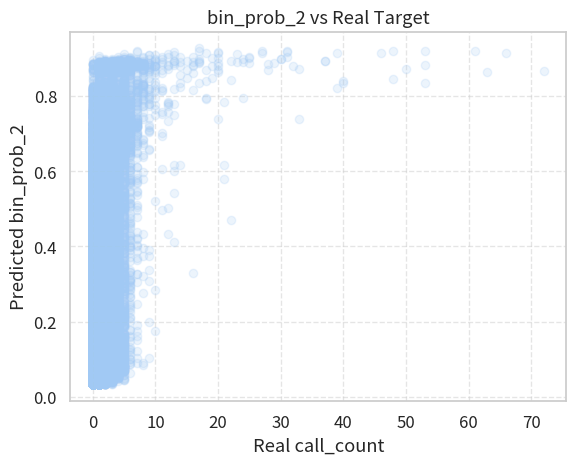

In [ ]:
# 1. 타겟 binning
def bin_target(y):
    if y == 0:
        return 0
    elif 1 <= y <= 5:
        return 1
    else:
        return 2

# 2. 분류 입력 구성 (train)
X = train_0903.drop(columns=['tm', 'call_count'])
y = train_0903['call_count']
y_bins = y.apply(bin_target)

# 3. 범주형 컬럼
cat_cols = ['cat', 'month', 'dayofweek', 'address_gu', 'full_address', 'stn', 'rn_day_bin']

# 4. 클래스 비율 기반 class_weights 계산
class_counts = y_bins.value_counts().sort_index()
total = class_counts.sum()
class_weights = (total / (len(class_counts) * class_counts)).values.tolist()
print(f"[Class weights] {class_weights}\n")

# 5. 시계열 기반 분할 + 분류 학습 (CatBoost)
tscv = TimeSeriesSplit(n_splits=3)
models = []
prob_oof = np.zeros((X.shape[0], y_bins.nunique()))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"[Fold {fold+1}] 진행 중...")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_bins.iloc[train_idx], y_bins.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        cat_features=cat_cols,
        eval_metric='Accuracy',
        class_weights=class_weights,
        random_state=42,
        verbose=0
    )

    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )

    # 6. 예측
    prob_oof[val_idx] = model.predict_proba(X_val)
    models.append(model)

# 7. 평가
oof_pred_bins = prob_oof.argmax(axis=1)

acc = accuracy_score(y_bins, oof_pred_bins)
print(f"\n[OOF Accuracy] {acc:.4f}")

print("\n[OOF Classification Report]")
print(classification_report(y_bins, oof_pred_bins))

# 8. 전체 데이터로 최종 모델 학습 후 예측 → 회귀 입력 생성
avg_best_iter = int(np.mean([m.best_iteration_ for m in models]))

final_model = CatBoostClassifier(
    iterations=avg_best_iter,  # or 300~500
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    cat_features=cat_cols,
    eval_metric='Accuracy',
    class_weights=class_weights,
    random_state=42,
    verbose=0
)
final_model.fit(X, y_bins)

X_proba = final_model.predict_proba(X)

plt.scatter(y, X_proba[:, 2], alpha=0.2)
plt.xlabel("Real call_count")
plt.ylabel("Predicted bin_prob_2")
plt.title("bin_prob_2 vs Real Target")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 9. 분류 입력 구성 (test)
X_test = test_0903.drop(columns=['tm', 'call_count'])

# 10. 예측
X_test_proba = final_model.predict_proba(X_test)

# 2단계 회귀 모델링

In [ ]:
# 1. 수치형 컬럼
num_cols = X.select_dtypes(include='number').columns.tolist()

# 2. 회귀 입력 구성 (train)
X_reg = pd.concat([
    pd.DataFrame(X_proba, columns=[f'bin_prob_{i}' for i in range(X_proba.shape[1])]),
    X[num_cols].reset_index(drop=True)
], axis=1)
y_log = np.log1p(y)

# 2. 회귀 학습 (FLAML)
automl = AutoML()
automl.fit(
    X_train=X_reg,
    y_train=y_log,
    metric='rmse',
    task='regression',
    n_jobs=-1,
    estimator_list='auto',
    time_budget=900,
    eval_method='cv',
    n_splits=3,
    retrain_full=True,
    split_type='time',
    seed=42,
    ensemble=False
)

# 3. 전체 예측 및 평가
y_pred_log = automl.predict(X_reg)
y_pred = np.expm1(y_pred_log)
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f"\n[FLAML 회귀 성능] RMSE: {rmse:.4f}, R²: {r2:.4f}")

# 4. 회귀 입력 구성 (test)
X_reg_test = pd.concat([
    pd.DataFrame(X_test_proba, columns=[f'bin_prob_{i}' for i in range(X_test_proba.shape[1])]),
    X_test[num_cols].reset_index(drop=True)
], axis=1)

# 5. 예측
y_test_pred_log = automl.predict(X_reg_test)
y_test_pred = np.expm1(y_test_pred_log)

# 6. 후처리: 음수 제거 + 반올림
y_test_pred = np.clip(y_test_pred, 0, None)             # 음수 제거
y_test_pred_rounded = np.round(y_test_pred).astype(int) # 정수 반올림

# 7. 결과 저장
test_result = test_0903[['tm', 'full_address']].copy()
test_result['pred_call_count'] = y_test_pred
test_result['pred_call_count_rounded'] = y_test_pred_rounded

[flaml.automl.logger: 06-26 14:23:05] {1752} INFO - task = regression
[flaml.automl.logger: 06-26 14:23:05] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 06-26 14:23:05] {1862} INFO - Minimizing error metric: rmse
[flaml.automl.logger: 06-26 14:23:05] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost']
[flaml.automl.logger: 06-26 14:23:05] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 06-26 14:23:06] {2417} INFO - Estimated sufficient time budget=8645s. Estimated necessary time budget=75s.
[flaml.automl.logger: 06-26 14:23:06] {2466} INFO -  at 1.8s,	estimator lgbm's best error=0.4094,	best estimator lgbm's best error=0.4094
[flaml.automl.logger: 06-26 14:23:06] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-26 14:23:07] {2466} INFO -  at 2.6s,	estimator lgbm's best error=0.4094,	best estimator lgbm's best error=0.4094
[flaml.automl.logger: 06-26 14:23

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 06-26 14:23:08] {2466} INFO -  at 4.1s,	estimator sgd's best error=0.4725,	best estimator lgbm's best error=0.3859
[flaml.automl.logger: 06-26 14:23:08] {2282} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 06-26 14:23:09] {2466} INFO -  at 5.1s,	estimator lgbm's best error=0.3487,	best estimator lgbm's best error=0.3487
[flaml.automl.logger: 06-26 14:23:09] {2282} INFO - iteration 5, current learner lgbm
[flaml.automl.logger: 06-26 14:23:10] {2466} INFO -  at 5.9s,	estimator lgbm's best error=0.3487,	best estimator lgbm's best error=0.3487
[flaml.automl.logger: 06-26 14:23:10] {2282} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 06-26 14:23:11] {2466} INFO -  at 7.4s,	estimator lgbm's best error=0.3483,	best estimator lgbm's best error=0.3483
[flaml.automl.logger: 06-26 14:23:11] {2282} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 06-26 14:23:13] {2466} INFO -  at 9.1s,	estimator lgbm's best error=0.3483,	best es

FLAML Best Estimator: XGBRegressor(base_score=None, booster=None, callbacks=[],
             colsample_bylevel=0.8851672386041315, colsample_bynode=None,
             colsample_bytree=0.9414474294855173, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.09523337152389842, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=1.1067513278027103, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=49,
             n_jobs=-1, num_parallel_tree=None, random_state=None, ...)
               feature  importance
6           weekofyear    0.003797
20    wind_gust_factor    0.003685
15              hm_min    0.003405
18       apparent_temp    0.00

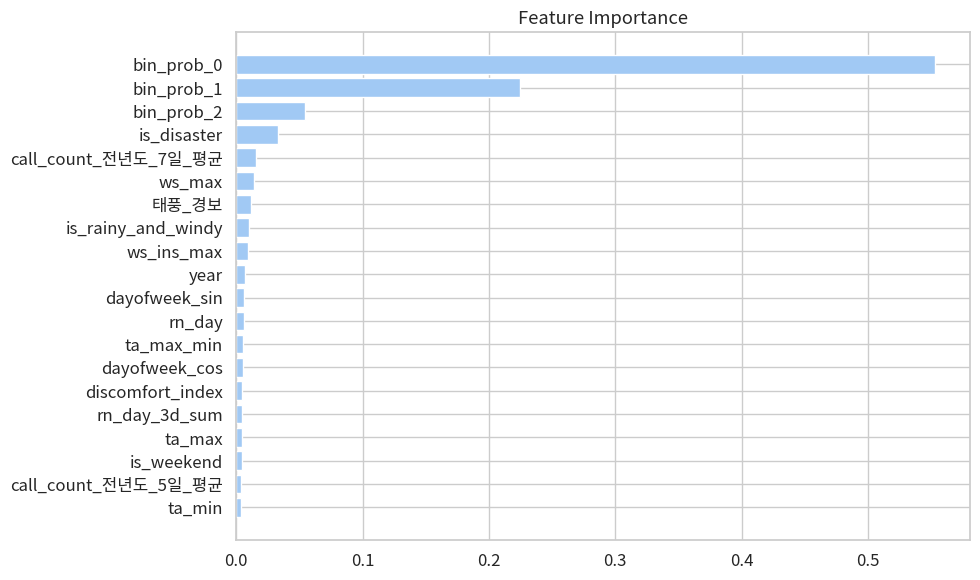

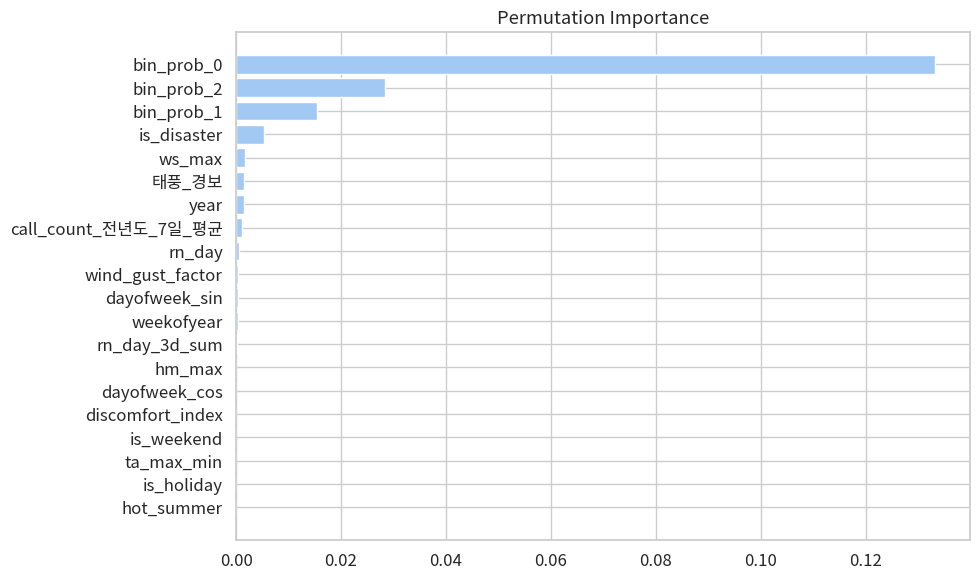

In [ ]:
print(f"FLAML Best Estimator: {automl.model.estimator}\n")

importances = automl.model.estimator.feature_importances_
feature_names = X_reg.columns

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

display(imp_df.tail(10)) # 하위 10개 확인

result = permutation_importance(
    automl.model.estimator,
    X_reg, y,
    n_repeats=10,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

display(perm_df.tail(10)) # 하위 10개 확인

# 시각화
top_k = 20
plt.figure(figsize=(10, 6))
plt.barh(imp_df.head(top_k)['feature'][::-1], imp_df.head(top_k)['importance'][::-1])
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(perm_df.head(top_k)['feature'][::-1], perm_df.head(top_k)['importance'][::-1])
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

In [ ]:
test_result.head(10)

,tm,full_address,pred_call_count,pred_call_count_rounded
0,2024-05-01,강서구_대저2동,0.687068,1
1,2024-05-01,강서구_대저2동,0.081592,0
2,2024-05-01,강서구_대저2동,0.097741,0
3,2024-05-01,강서구_생곡동,0.687068,1
4,2024-05-01,강서구_생곡동,0.081592,0
5,2024-05-01,강서구_생곡동,0.097741,0
6,2024-05-01,강서구_송정동,0.754837,1
7,2024-05-01,강서구_송정동,0.085065,0
8,2024-05-01,강서구_송정동,0.371285,0
9,2024-05-01,강서구_신호동,0.751688,1


In [ ]:
test_agg = test_result.groupby(['tm', 'full_address'], observed=True).agg(
    pred=('pred_call_count', 'sum'),
    pred_rounded=('pred_call_count_rounded', 'sum'),
).reset_index()

test_agg.head(10)

,tm,full_address,pred,pred_rounded
0,2024-05-01,강서구_대저2동,0.866401,1
1,2024-05-01,강서구_생곡동,0.866401,1
2,2024-05-01,강서구_송정동,1.211187,1
3,2024-05-01,강서구_신호동,1.161369,1
4,2024-05-01,금정구_구서동,1.010853,1
5,2024-05-01,금정구_남산동,1.159125,1
6,2024-05-01,금정구_부곡동,1.194745,1
7,2024-05-01,금정구_청룡동,0.875023,1
8,2024-05-01,기장군_기장읍,1.658985,1
9,2024-05-01,기장군_장안읍,0.954107,1


In [ ]:
test_result.shape

(28803, 4)

In [ ]:
test_agg = test_result.groupby(['tm', 'full_address'], observed=True).agg(
    pred=('pred_call_count', 'sum'),
    pred_rounded=('pred_call_count_rounded', 'sum'),
).reset_index()

test_agg['pred'] = np.round(test_agg['pred'])
test_agg['pred'] = test_agg['pred'].apply(lambda x: 1 if x <= 1 else x)
test_agg['pred_rounded'] = test_agg['pred_rounded'].apply(lambda x: 1 if x <= 1 else x)

test_agg['pred'].value_counts()

,count
pred,
1.0,6375
2.0,2930
3.0,108
6.0,91
5.0,59
4.0,20
7.0,14
8.0,4


In [ ]:
test_agg.to_csv('call119_submit_stacking.csv', index=False, encoding='utf-8-sig')